In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import tree
import joblib

In [ ]:
df = pd.read_csv("data.csv")
df

In [48]:
df.drop(["id", 'Unnamed: 32'], axis=1, inplace=True)

In [49]:
print((df["diagnosis"] == "M").sum())

212


In [50]:
print((df["diagnosis"] == "B").sum())

357


In [51]:
df["diagnosis"] = (df["diagnosis"] == "M").astype(int)

In [52]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [53]:
df.corr()['diagnosis'].sort_values(ascending=False)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

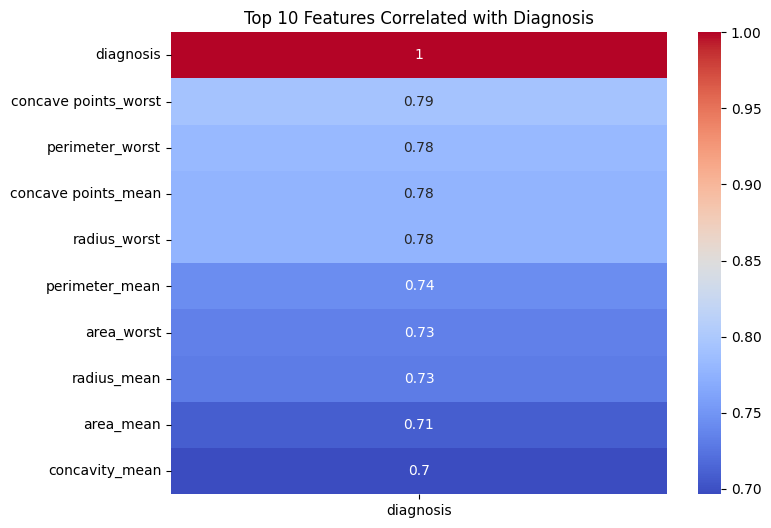

In [54]:
top_corr = df.corr()[['diagnosis']].sort_values(by='diagnosis', ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.heatmap(top_corr, annot=True, cmap='coolwarm', fmt='.2g')
plt.title("Top 10 Features Correlated with Diagnosis")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_18300\397175539.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")


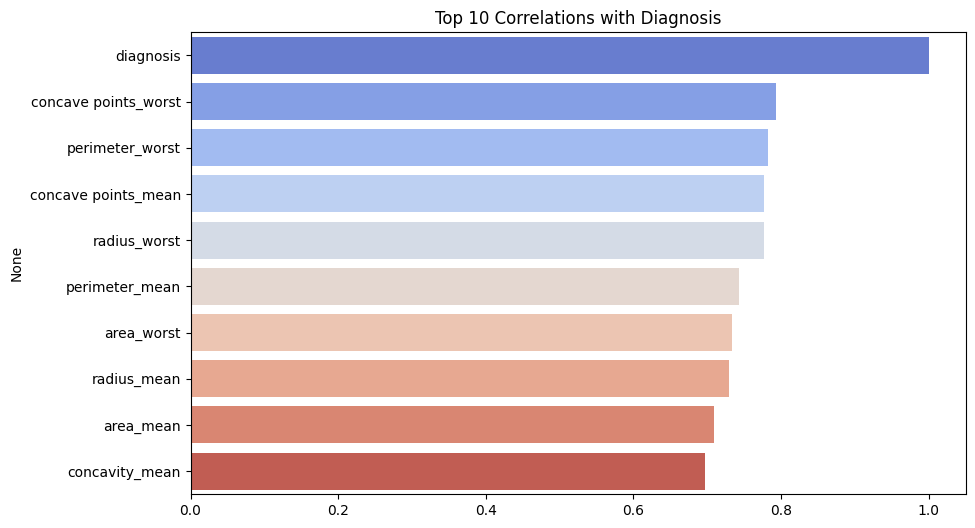

In [55]:
top_corr = df.corr()['diagnosis'].sort_values(ascending=False).nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")
plt.title("Top 10 Correlations with Diagnosis")
plt.show()


In [56]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

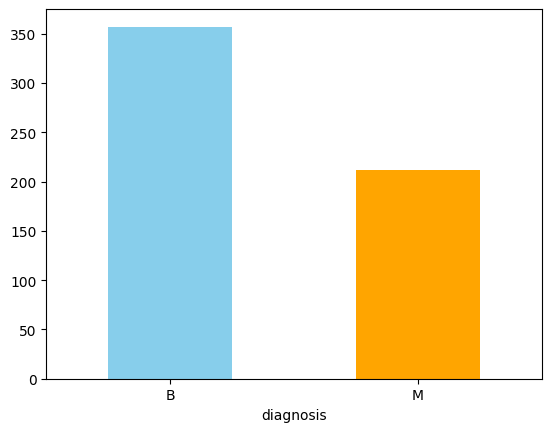

In [57]:
df["diagnosis"].value_counts().plot(kind="bar", color=["skyblue", "orange"])
plt.xticks(ticks=[0, 1], labels=["B", "M"], rotation=0)
plt.show()

In [76]:
X = df.drop(["diagnosis"], axis=1)
y = df["diagnosis"]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# DecisionTreeClassifier


In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
clf = DecisionTreeClassifier(ccp_alpha=0.01)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
clf.get_params()

{'ccp_alpha': 0.01,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [ ]:
y_pred = clf.predict(X_test)

In [64]:
accuracy_score(y_test, y_pred)

0.956140350877193

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [18]:
feature_names = x.columns
feature_names

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [19]:
clf.feature_importances_

array([0.        , 0.03470188, 0.        , 0.02672775, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.85797814, 0.        , 0.        ,
       0.        , 0.        , 0.08059223, 0.        , 0.        ,
       0.        ])

In [20]:
feature_importance = pd.DataFrame(
    clf.feature_importances_, index=feature_names, columns=["Importance"]
)


feature_importance

,Importance
radius_mean,0.000000
texture_mean,0.034702
perimeter_mean,0.000000
area_mean,0.026728
smoothness_mean,0.000000
compactness_mean,0.000000
concavity_mean,0.000000
concave points_mean,0.000000
symmetry_mean,0.000000
fractal_dimension_mean,0.000000


In [21]:
feature_importance.sort_values(by="Importance", ascending=False, inplace=True)

In [22]:
feature_importance

,Importance
perimeter_worst,0.857978
concave points_worst,0.080592
texture_mean,0.034702
area_mean,0.026728
radius_mean,0.000000
concave points_se,0.000000
fractal_dimension_worst,0.000000
symmetry_worst,0.000000
concavity_worst,0.000000
compactness_worst,0.000000


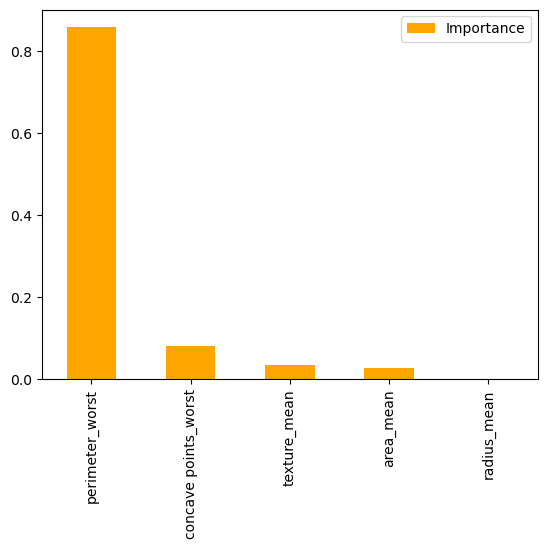

In [23]:
feature_importance.head().plot(kind="bar", color="orange")
plt.show()

In [67]:
fig = plt.figure(figsize=(20, 20))
_ = tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names={0: "Malignant", 1: "Bening"},
    filled=True,
    fontsize=12,
)

NameError: name 'feature_names' is not defined

<Figure size 2000x2000 with 0 Axes>

## XGB model


In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = xgb.predict(X_test)

In [69]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97        72
           1       0.93      0.95      0.94        42

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [71]:
accuracy_score(y_pred, y_test)

0.956140350877193

In [83]:
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

In [84]:
cols_to_scale = ["perimeter_mean", "area_mean", "perimeter_worst","area_worst"]

transform = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), 'cols_to_scale')
    ]
)

pipe = Pipeline([
    ('preprocessor', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('sampler', SMOTE()),
    ('model', XGBClassifier())
])

pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


In [85]:
y_pred = pipe.predict(X_test)

In [86]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [89]:
joblib.dump(pipe, "model.joblib")

['model.joblib']